## Imports and connection

In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect("../data/checking-logs.sqlite")

## Get datetimes from pageviews (users only)

In [2]:
query = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%';
"""
df = pd.io.sql.read_sql(query, con, parse_dates=["datetime"])
df.head()

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144


## Count views per day

In [3]:
df["date"] = df["datetime"].dt.date
views_per_day = df.groupby("date").size()
views_per_day.head()

date
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
dtype: int64

## Plot fontsize=8, figsize=(15,8), title = “Views per Day”  + rotation

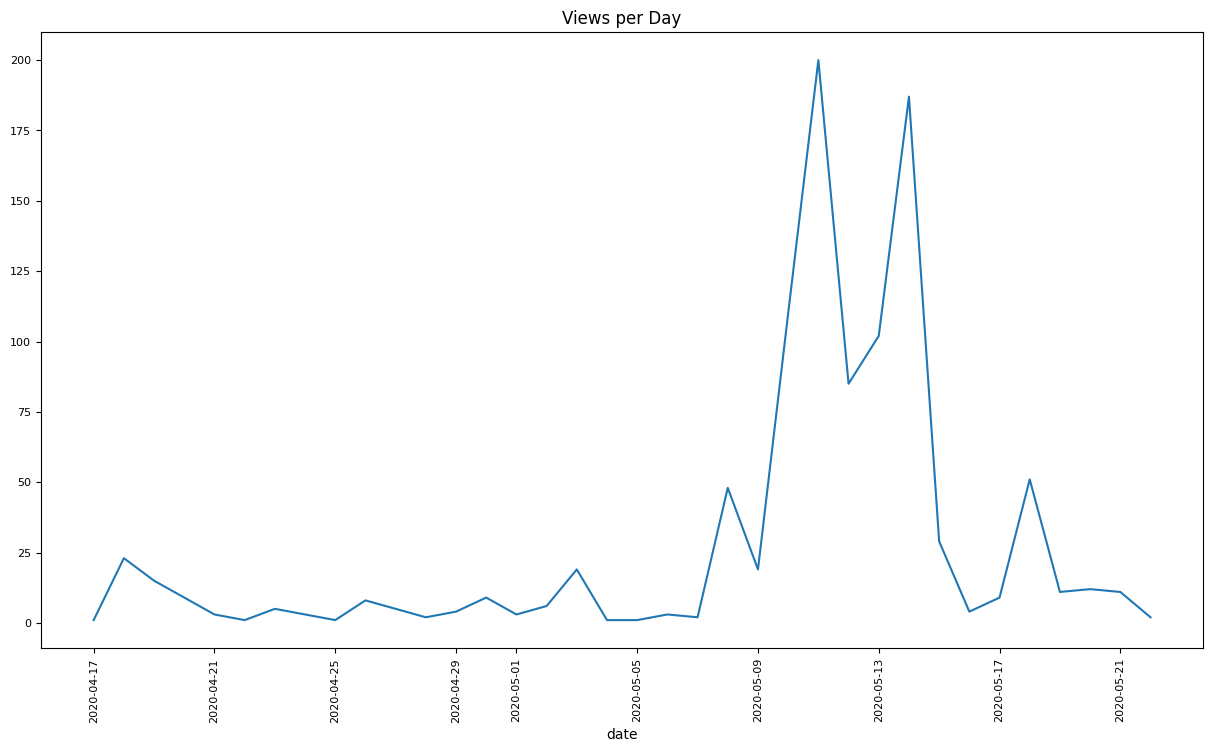

In [5]:
ax = views_per_day.plot(figsize=(15, 8), fontsize=8, title="Views per Day")
ax.tick_params(axis="x", rotation=90)

In [6]:
con.close()